In [1]:
import pandas as pd
footfalls_df= pd.read_csv("D:\\csv files\\footfalls.csv")
footfalls_df.head()

,Month,Footfalls
0,Jan-91,1709
1,Feb-91,1621
2,Mar-91,1973
3,Apr-91,1812
4,May-91,1975


In [2]:
footfalls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Month      159 non-null    object
 1   Footfalls  159 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.6+ KB


In [3]:
# step1 and step 2 EDA+ Data Cleaning
footfalls_ts = footfalls_df[['Month', 'Footfalls']].copy()

footfalls_ts['Month'] = pd.to_datetime(
    footfalls_ts['Month'],
    format='%b-%y'
)

footfalls_ts.head()

footfalls_ts.set_index('Month', inplace=True)

footfalls_ts.head()

footfalls_ts.isnull().sum()


Footfalls    0
dtype: int64

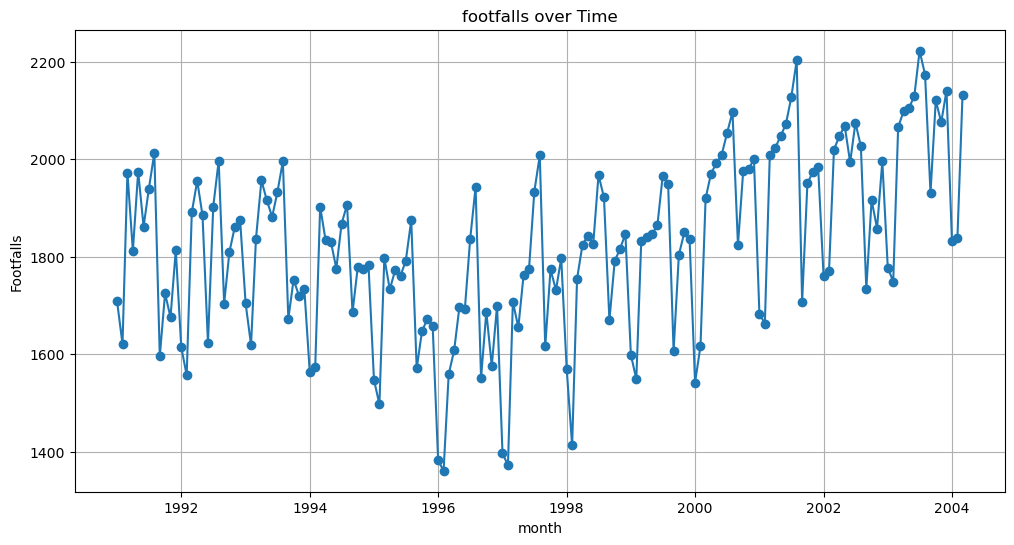

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(footfalls_ts,marker='o')
plt.title('footfalls over Time')
plt.xlabel('month')
plt.ylabel('Footfalls')
plt.grid(True)
plt.show()


In [5]:
#ADF Test
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
    result=adfuller(series)
    return 
    {
    'ADF Statistic' : result[0],
    'p-value' : result[1],
    'critical values' : result[4]
    }
adf_result_original=adf_test(footfalls_ts['Footfalls'])
adf_result_original

In [6]:
# Applying Differences
footfalls_diff=footfalls_ts['Footfalls'].diff().dropna()
footfalls_diff.head()
adf_result_diff=adf_test(footfalls_diff)
adf_result_diff


In [7]:
# first fit on AR model
import warnings 
warnings.filterwarnings("ignore")
from statsmodels.tsa.arima.model import ARIMA
ar_model=ARIMA(footfalls_ts['Footfalls'], order=(1,0,0))
ar_model_fit=ar_model.fit()
ar_summary=ar_model_fit.summary()
print("AIC:", ar_model_fit.aic)
print("BIC:", ar_model_fit.bic)
from sklearn.metrics import mean_squared_error
import numpy as np
rmse=np.sqrt(mean_squared_error(footfalls_ts['Footfalls'],ar_model_fit.fittedvalues))
print("RMSE:",rmse)


AIC: 2049.473493154207
BIC: 2058.680205760868
RMSE: 149.37102270934497


In [8]:
# MA Model
from statsmodels.tsa.arima.model import ARIMA
ma_model=ARIMA(footfalls_ts['Footfalls'], order=(0,0,1))
ma_model_fit=ma_model.fit()
ma_summary=ma_model_fit.summary()
print("AIC:", ma_model_fit.aic)
print("BIC:", ma_model_fit.bic)
from sklearn.metrics import mean_squared_error
import numpy as np
rmse=np.sqrt(mean_squared_error(footfalls_ts['Footfalls'],ma_model_fit.fittedvalues))
print("RMSE:", rmse)

AIC: 2062.9624044273983
BIC: 2072.169117034059
RMSE: 155.89074987835144


In [13]:
#ARIMA Model
from statsmodels.tsa.arima.model import ARIMA
arima_model=ARIMA(footfalls_ts['Footfalls'],order=(1,1,1))
arima_model_fit=arima_model.fit()
arima_summary=arima_model_fit.summary()
print("AIC:", arima_model_fit.aic)
print("BIC:", arima_model_fit.bic)
from sklearn.metrics import mean_squared_error
import numpy as np
rmse=np.sqrt(mean_squared_error(footfalls_ts['Footfalls'],arima_model_fit.fittedvalues))
print("RMSE:", rmse)

AIC: 2026.0772982574636
BIC: 2035.2650833565444
RMSE: 197.98443949139988


In [18]:
# To Print ai, bi, RMSE vales of ar, ma, and arima models
from sklearn.metrics import mean_squared_error
import numpy as np
def caliculate_rmse(actual, predicted):
    retrun= np.sqrt(mean_squared_error(actual, predicted))
ar_pred_in_sample=ar_model_fit.predict(start=footfalls_ts.index[0],end=footfalls_ts.index[-1])
ma_pred_in_sample=ma_model_fit.predict(start=footfalls_ts.index[0], end=footfalls_ts.index[-1])
arima_pred_in_sample=arima_model_fit.predict(start=footfalls_ts.index[0], end=footfalls_ts.index[-1])
metrics={
    'Model': ['AR(1)', 'MA(1)', 'ARIMA(1,1,1)'],
    'AIC' : [ar_model_fit.aic,
             ma_model_fit.aic,
             arima_model_fit.aic],
    'BIC' : [ar_model_fit.bic,
             ma_model_fit.bic,
             arima_model_fit.bic],
'RMSE' : [caliculate_rmse(footfalls_ts['Footfalls'], ar_pred_in_sample),
          caliculate_rmse(footfalls_ts['Footfalls'], ma_pred_in_sample),
          caliculate_rmse(footfalls_ts['Footfalls'], arima_pred_in_sample)
         ]}
metrics_df=pd.DataFrame(metrics)
metrics_df

,Model,AIC,BIC,RMSE
0,AR(1),2049.473493,2058.680206,None
1,MA(1),2062.962404,2072.169117,None
2,"ARIMA(1,1,1)",2026.077298,2035.265083,None
